
# PRImA Document Image Segmentation with U-Net

End-to-end workflow:
1. Pair document images with PAGE-XML.
2. Parse XML polygons robustly.
3. Rasterize full-resolution ground-truth masks.
4. Use `0` as an **implicit background** and `1..10` for the ten PRImA region classes.
5. Train a U-Net on the ten XML-defined foreground classes only.
6. Predict with foreground `argmax` + a confidence threshold for background.
7. Evaluate IoU/Dice.
8. Visualize aligned ground truth and predictions.
9. Extract class-specific bottleneck feature vectors.
10. Build class prototypes and perform feature analysis.

PRImA has no explicit `BackgroundRegion`; background is therefore derived from pixels not covered by recognized XML regions.


In [25]:

# 1. Imports and reproducibility

# Fresh environment only:
# %pip install -q torch torchvision torchinfo opencv-python-headless pillow matplotlib tqdm scikit-learn pandas

import os
import re
import random
import warnings
import xml.etree.ElementTree as ET
from pathlib import Path
from collections import Counter

import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
from tqdm.auto import tqdm
from sklearn.model_selection import train_test_split
from sklearn.decomposition import PCA

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

try:
    from torchinfo import summary
except ImportError:
    summary = None

SEED = 14
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", DEVICE)
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))


Device: cuda
GPU: NVIDIA GeForce GTX 1080 Ti


In [26]:

# 2. Paths

PROJECT_ROOT = Path.cwd()
DATASET_ROOT = Path.home() / "abhista" / "datasets" / "PRImALayoutAnalysisDataset"

IMAGE_DIR = DATASET_ROOT / "Images"
XML_DIR = DATASET_ROOT / "XML"

MASK_DIR = DATASET_ROOT / "generated_masks_corrected"
PREDICTION_DIR = DATASET_ROOT / "predictions_corrected"
FEATURE_DIR = DATASET_ROOT / "deep_features_corrected"

CHECKPOINT_PATH = DATASET_ROOT / "best_unet_prima_corrected.pth"
FINAL_MODEL_PATH = DATASET_ROOT / "prima_unet_final_corrected.pth"
HISTORY_PATH = DATASET_ROOT / "unet_training_history_corrected.csv"
RESULTS_PATH = DATASET_ROOT / "unet_test_results_corrected.csv"

for d in (MASK_DIR, PREDICTION_DIR, FEATURE_DIR):
    d.mkdir(parents=True, exist_ok=True)

if not IMAGE_DIR.exists():
    raise FileNotFoundError(f"Image directory not found: {IMAGE_DIR}")
if not XML_DIR.exists():
    raise FileNotFoundError(f"XML directory not found: {XML_DIR}")

print("Dataset:", DATASET_ROOT)
print("Images :", IMAGE_DIR)
print("XML    :", XML_DIR)


Dataset: /data1/students/abhista/datasets/PRImALayoutAnalysisDataset
Images : /data1/students/abhista/datasets/PRImALayoutAnalysisDataset/Images
XML    : /data1/students/abhista/datasets/PRImALayoutAnalysisDataset/XML


In [27]:

# 3. One class mapping used everywhere

# 0 = implicit background. It is not an XML region and is NOT optimized by the loss.
# 1..10 = the ten trainable PRImA foreground classes.

CLASS_NAMES = [
    "background",
    "text",
    "image",
    "line_drawing",
    "graphic",
    "table",
    "chart",
    "separator",
    "maths",
    "noise",
    "frame",
]

CLASS_TO_ID = {name: i for i, name in enumerate(CLASS_NAMES)}
ID_TO_CLASS = {i: name for name, i in CLASS_TO_ID.items()}

REGION_TYPES = {
    "TextRegion": "text",
    "ImageRegion": "image",
    "LineDrawingRegion": "line_drawing",
    "GraphicRegion": "graphic",
    "TableRegion": "table",
    "ChartRegion": "chart",
    "SeparatorRegion": "separator",
    "MathsRegion": "maths",
    "NoiseRegion": "noise",
    "FrameRegion": "frame",
}

FOREGROUND_CLASS_NAMES = CLASS_NAMES[1:]
FOREGROUND_IDS = list(range(1, len(CLASS_NAMES)))
NUM_CLASSES = len(FOREGROUND_CLASS_NAMES)  # U-Net output channels
IGNORE_INDEX = 255

print(CLASS_TO_ID)
print("U-Net output channels:", NUM_CLASSES)


{'background': 0, 'text': 1, 'image': 2, 'line_drawing': 3, 'graphic': 4, 'table': 5, 'chart': 6, 'separator': 7, 'maths': 8, 'noise': 9, 'frame': 10}
U-Net output channels: 10



## XML-to-mask rules

The parser removes PAGE-XML namespaces by taking the local tag name. For every recognized region, coordinates are read from `Point x/y` elements, with a `points="x,y ..."` fallback.

Malformed polygons (<3 valid points) are skipped and reported. Coordinates outside the page are clipped. The mask is initialized to background `0`. For overlapping polygons, XML order is deterministic: a later polygon overwrites an earlier one, and overlap pixels are counted so the ambiguity is visible rather than hidden. Unknown region tags are reported and are **not** silently assigned to another class.


In [28]:

# 4. Robust PAGE-XML polygon parsing

def local_name(tag):
    return tag.rsplit("}", 1)[-1] if isinstance(tag, str) else ""

def parse_coordinate_pairs(points_string):
    if not points_string:
        return np.empty((0, 2), dtype=np.float32)
    points = []
    for token in re.split(r"\s+", points_string.strip()):
        if "," not in token:
            continue
        x_s, y_s = token.split(",")[:2]
        try:
            x, y = float(x_s), float(y_s)
        except ValueError:
            continue
        if np.isfinite(x) and np.isfinite(y):
            points.append((x, y))
    return np.asarray(points, dtype=np.float32).reshape(-1, 2)

def extract_region_polygon(region_element):
    for coords in region_element.iter():
        if local_name(coords.tag) != "Coords":
            continue

        points = []
        for child in list(coords):
            if local_name(child.tag) != "Point":
                continue
            try:
                x = float(child.attrib["x"])
                y = float(child.attrib["y"])
            except (KeyError, ValueError):
                continue
            if np.isfinite(x) and np.isfinite(y):
                points.append((x, y))

        points = np.asarray(points, dtype=np.float32).reshape(-1, 2)
        if len(points) >= 3:
            return points

        fallback = parse_coordinate_pairs(coords.attrib.get("points"))
        if len(fallback) >= 3:
            return fallback

    return np.empty((0, 2), dtype=np.float32)

def clip_polygon(polygon, width, height):
    if len(polygon) == 0:
        return np.empty((0, 2), dtype=np.int32)
    polygon = np.rint(polygon).astype(np.int32)
    polygon[:, 0] = np.clip(polygon[:, 0], 0, width - 1)
    polygon[:, 1] = np.clip(polygon[:, 1], 0, height - 1)

    # Remove consecutive duplicates.
    if len(polygon) > 1:
        keep = np.ones(len(polygon), dtype=bool)
        keep[1:] = np.any(polygon[1:] != polygon[:-1], axis=1)
        polygon = polygon[keep]
    return polygon


In [29]:

# 5. XML -> full-resolution semantic mask

def xml_to_mask(xml_path, image_width, image_height, return_report=False):
    mask = np.zeros((image_height, image_width), dtype=np.uint8)

    report = {
        "xml": str(xml_path),
        "regions_seen": 0,
        "regions_rasterized": 0,
        "malformed_regions": 0,
        "clipped_regions": 0,
        "overlap_pixels": 0,
        "unknown_region_types": Counter(),
    }

    try:
        root = ET.parse(xml_path).getroot()
    except ET.ParseError as exc:
        raise ValueError(f"Malformed XML: {xml_path}\n{exc}") from exc

    for element in root.iter():
        tag = local_name(element.tag)
        if not tag.endswith("Region"):
            continue

        report["regions_seen"] += 1

        if tag not in REGION_TYPES:
            report["unknown_region_types"][tag] += 1
            continue

        polygon = extract_region_polygon(element)
        if len(polygon) < 3:
            report["malformed_regions"] += 1
            continue

        if (
            np.any(polygon[:, 0] < 0) or
            np.any(polygon[:, 0] >= image_width) or
            np.any(polygon[:, 1] < 0) or
            np.any(polygon[:, 1] >= image_height)
        ):
            report["clipped_regions"] += 1

        polygon = clip_polygon(polygon, image_width, image_height)
        if len(polygon) < 3:
            report["malformed_regions"] += 1
            continue

        class_id = CLASS_TO_ID[REGION_TYPES[tag]]

        region_mask = np.zeros_like(mask)
        cv2.fillPoly(region_mask, [polygon], int(class_id))

        occupied = region_mask > 0
        report["overlap_pixels"] += int(np.count_nonzero(occupied & (mask > 0)))

        # Deterministic overlap rule: later XML region wins.
        mask[occupied] = class_id
        report["regions_rasterized"] += 1

    return (mask, report) if return_report else mask


def create_image_xml_pairs(image_dir, xml_dir):
    extensions = {".jpg", ".jpeg", ".png", ".tif", ".tiff", ".bmp"}

    images = sorted(
        p for p in Path(image_dir).rglob("*")
        if p.is_file() and p.suffix.lower() in extensions
    )
    xmls = sorted(Path(xml_dir).rglob("*.xml"))

    def key(p):
        return p.stem.lower().removeprefix("pc-")

    lookup = {key(p): p for p in xmls}
    pairs, missing = [], []

    for image in images:
        xml = lookup.get(key(image))
        if xml is None:
            missing.append(image)
        else:
            pairs.append((image, xml))

    return pairs, missing

pairs, missing_xml = create_image_xml_pairs(IMAGE_DIR, XML_DIR)
print("Pairs:", len(pairs))
print("Images without XML:", len(missing_xml))

if not pairs:
    raise RuntimeError("No image/XML pairs found.")

for image_path, xml_path in pairs[:10]:
    print(image_path.name, "<->", xml_path.name)


Pairs: 478
Images without XML: 0
00000085.tif <-> pc-00000085.xml
00000086.tif <-> 00000086.xml
00000087.tif <-> 00000087.xml
00000088.tif <-> pc-00000088.xml
00000089.tif <-> 00000089.xml
00000090.tif <-> 00000090.xml
00000122.tif <-> 00000122.xml
00000124.tif <-> 00000124.xml
00000125.tif <-> 00000125.xml
00000126.tif <-> 00000126.xml


In [30]:

# 6. Generate corrected masks

mask_reports = []

for image_path, xml_path in tqdm(pairs, desc="Generating masks"):
    with Image.open(image_path) as image:
        width, height = image.size

    mask, report = xml_to_mask(
        xml_path, width, height, return_report=True
    )

    mask_path = MASK_DIR / f"{image_path.stem}.png"
    Image.fromarray(mask, mode="L").save(mask_path)

    report["image"] = str(image_path)
    report["mask"] = str(mask_path)
    mask_reports.append(report)

mask_report_df = pd.DataFrame(mask_reports)

unknown = Counter()
for c in mask_report_df["unknown_region_types"]:
    unknown.update(c)

print("Generated:", len(mask_report_df))
print("Malformed:", int(mask_report_df["malformed_regions"].sum()))
print("Clipped  :", int(mask_report_df["clipped_regions"].sum()))
print("Overlap pixels:", int(mask_report_df["overlap_pixels"].sum()))
print("Unknown XML region types:", dict(unknown))


Generating masks: 100%|██████████| 478/478 [01:23<00:00,  5.75it/s]

Generated: 478
Malformed: 39
Clipped  : 1
Overlap pixels: 13788
Unknown XML region types: {}


In [31]:

# 7. Validate mask IDs and class distribution

counts = np.zeros(len(CLASS_NAMES), dtype=np.int64)

for path in MASK_DIR.glob("*.png"):
    mask = np.asarray(Image.open(path), dtype=np.uint8)
    values, n = np.unique(mask, return_counts=True)
    for value, count in zip(values, n):
        if int(value) >= len(CLASS_NAMES):
            raise ValueError(f"Invalid class ID {value} in {path}")
        counts[int(value)] += int(count)

mask_statistics = pd.DataFrame({
    "class_id": range(len(CLASS_NAMES)),
    "class": CLASS_NAMES,
    "pixels": counts,
})
mask_statistics["percentage"] = 100 * mask_statistics["pixels"] / counts.sum()
display(mask_statistics)


,class_id,class,pixels,percentage
0,0,background,1507287228,41.706679
1,1,text,1577284479,43.643505
2,2,image,418543597,11.581113
3,3,line_drawing,7517778,0.208017
4,4,graphic,40236132,1.113335
5,5,table,28888034,0.799333
6,6,chart,18889588,0.522675
7,7,separator,8590757,0.237706
8,8,maths,2568344,0.071066
9,9,noise,707955,0.019589


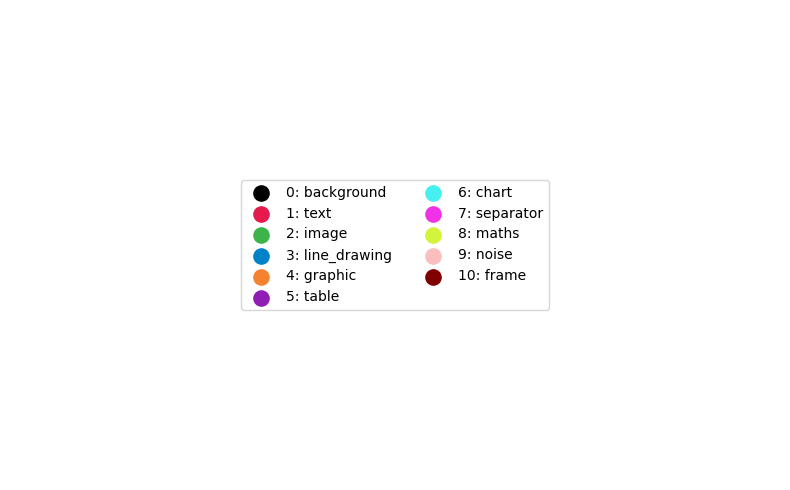

In [32]:

# 8. Fixed palette used in every visualization

CLASS_COLORS = {
    0: (0, 0, 0),
    1: (230, 25, 75),
    2: (60, 180, 75),
    3: (0, 130, 200),
    4: (245, 130, 48),
    5: (145, 30, 180),
    6: (70, 240, 240),
    7: (240, 50, 230),
    8: (210, 245, 60),
    9: (250, 190, 190),
    10: (128, 0, 0),
}

def colorize_mask(mask):
    rgb = np.zeros((*mask.shape, 3), dtype=np.uint8)
    for class_id, color in CLASS_COLORS.items():
        rgb[mask == class_id] = color
    return rgb

def overlay_mask(image_rgb, mask, alpha=0.45):
    colored = colorize_mask(mask)
    out = image_rgb.astype(np.float32).copy()
    fg = mask != 0
    out[fg] = (1 - alpha) * out[fg] + alpha * colored[fg]
    return np.clip(out, 0, 255).astype(np.uint8)

def show_class_legend():
    fig, ax = plt.subplots(figsize=(8, 5))
    for class_id, name in enumerate(CLASS_NAMES):
        ax.scatter([], [], s=120,
                   color=np.asarray(CLASS_COLORS[class_id]) / 255,
                   label=f"{class_id}: {name}")
    ax.legend(loc="center", ncol=2)
    ax.axis("off")
    plt.tight_layout()
    plt.show()

show_class_legend()


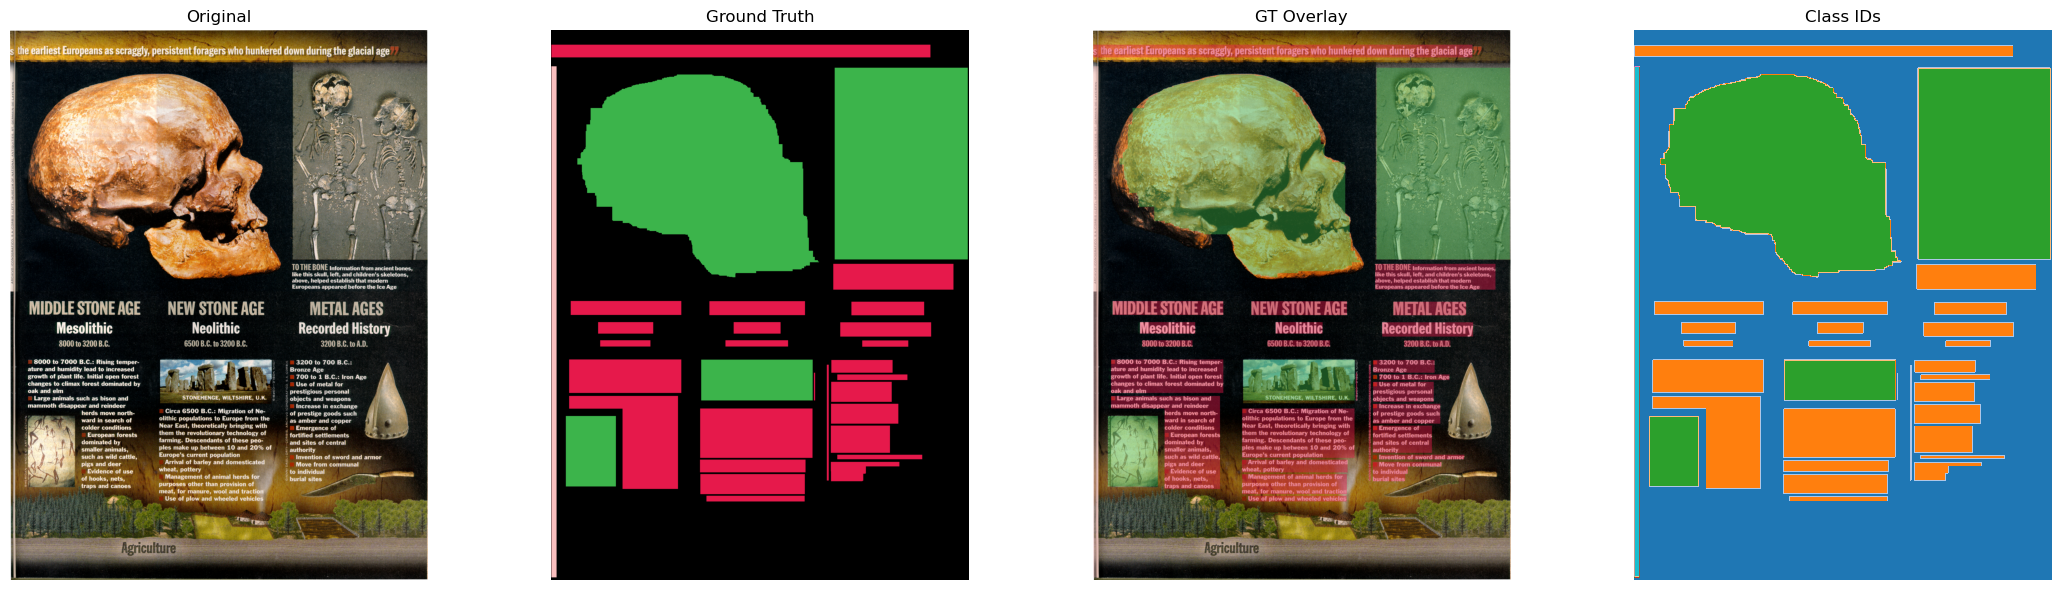

In [33]:

# 9. Ground-truth visualization at original resolution

def visualize_ground_truth(image_path, mask_path):
    image = np.asarray(Image.open(image_path).convert("RGB"))
    mask = np.asarray(Image.open(mask_path), dtype=np.uint8)

    if image.shape[:2] != mask.shape:
        raise ValueError(f"Image/mask mismatch: {image.shape[:2]} vs {mask.shape}")

    fig, ax = plt.subplots(1, 4, figsize=(22, 6))
    ax[0].imshow(image); ax[0].set_title("Original")
    ax[1].imshow(colorize_mask(mask)); ax[1].set_title("Ground Truth")
    ax[2].imshow(overlay_mask(image, mask)); ax[2].set_title("GT Overlay")
    ax[3].imshow(mask, cmap="tab20", vmin=0, vmax=10); ax[3].set_title("Class IDs")
    for a in ax: a.axis("off")
    plt.tight_layout()
    plt.show()

sample_image_path, sample_xml_path = pairs[min(5, len(pairs)-1)]
sample_mask_path = MASK_DIR / f"{Path(sample_image_path).stem}.png"
visualize_ground_truth(sample_image_path, sample_mask_path)


In [34]:

# 10. Dataset split

dataset_items = [
    {
        "image": str(image_path),
        "xml": str(xml_path),
        "mask": str(MASK_DIR / f"{image_path.stem}.png"),
    }
    for image_path, xml_path in pairs
    if (MASK_DIR / f"{image_path.stem}.png").exists()
]

train_items, temp_items = train_test_split(
    dataset_items, test_size=0.30, random_state=SEED, shuffle=True
)
val_items, test_items = train_test_split(
    temp_items, test_size=0.50, random_state=SEED, shuffle=True
)

print(len(dataset_items), "total")
print(len(train_items), "train")
print(len(val_items), "validation")
print(len(test_items), "test")


478 total
334 train
72 validation
72 test



## Spatially consistent preprocessing

The original notebook resized every page directly to `512×512`, which can distort document geometry. The revised pipeline uses aspect-ratio-preserving letterbox resizing.

The **same geometric transform** is applied to the image and mask. Images use bilinear/area interpolation; masks use nearest-neighbor interpolation so class IDs remain integers. Predictions are mapped back to original page coordinates for visualization and evaluation.


In [35]:

# 11. Dataset configuration and aspect-ratio-preserving preprocessing

IMAGE_SIZE = 512
BATCH_SIZE = 4
NUM_WORKERS = 2
LEARNING_RATE = 1e-4
NUM_EPOCHS = 30
WEIGHT_DECAY = 1e-5
BASE_CHANNELS = 32
BACKGROUND_THRESHOLD = 0.50

def letterbox(image, mask, size):
    h, w = image.shape[:2]
    scale = min(size / w, size / h)
    nw, nh = max(1, round(w * scale)), max(1, round(h * scale))

    image_r = cv2.resize(image, (nw, nh), interpolation=cv2.INTER_AREA)
    mask_r = cv2.resize(mask, (nw, nh), interpolation=cv2.INTER_NEAREST)

    canvas_i = np.zeros((size, size, 3), dtype=np.uint8)
    canvas_m = np.zeros((size, size), dtype=np.uint8)

    top = (size - nh) // 2
    left = (size - nw) // 2

    canvas_i[top:top+nh, left:left+nw] = image_r
    canvas_m[top:top+nh, left:left+nw] = mask_r

    return canvas_i, canvas_m

class PRImADataset(Dataset):
    def __init__(self, items, image_size=512, augment=False):
        self.items = items
        self.image_size = image_size
        self.augment = augment

    def __len__(self):
        return len(self.items)

    def __getitem__(self, index):
        item = self.items[index]

        image = np.asarray(Image.open(item["image"]).convert("RGB"), dtype=np.uint8)
        mask = np.asarray(Image.open(item["mask"]), dtype=np.uint8)

        image, mask = letterbox(image, mask, self.image_size)

        if self.augment:
            if random.random() < 0.5:
                image = np.fliplr(image).copy()
                mask = np.fliplr(mask).copy()
            if random.random() < 0.5:
                image = np.flipud(image).copy()
                mask = np.flipud(mask).copy()

        image = torch.from_numpy(
            image.astype(np.float32).transpose(2, 0, 1) / 255.0
        )

        # Background is not a training target.
        target = mask.astype(np.int64)
        target[target == 0] = IGNORE_INDEX

        return image, torch.from_numpy(target), torch.from_numpy(mask.astype(np.int64))


In [36]:

# 12. DataLoaders

train_dataset = PRImADataset(train_items, IMAGE_SIZE, augment=True)
val_dataset = PRImADataset(val_items, IMAGE_SIZE, augment=False)
test_dataset = PRImADataset(test_items, IMAGE_SIZE, augment=False)

loader_kwargs = dict(
    batch_size=BATCH_SIZE,
    num_workers=NUM_WORKERS,
    pin_memory=torch.cuda.is_available(),
    persistent_workers=(NUM_WORKERS > 0),
)

train_loader = DataLoader(train_dataset, shuffle=True, **loader_kwargs)
val_loader = DataLoader(val_dataset, shuffle=False, **loader_kwargs)
test_loader = DataLoader(test_dataset, shuffle=False, **loader_kwargs)

images, targets, raw_masks = next(iter(train_loader))
print("Images:", images.shape)
print("Training targets:", targets.shape)
print("Raw masks:", raw_masks.shape)
print("Image range:", float(images.min()), float(images.max()))
print("Foreground target IDs:", torch.unique(targets[targets != IGNORE_INDEX]).tolist())


Images: torch.Size([4, 3, 512, 512])
Training targets: torch.Size([4, 512, 512])
Raw masks: torch.Size([4, 512, 512])
Image range: 0.0 1.0
Foreground target IDs: [1, 2, 7, 9]


In [37]:

# 13. Self-contained U-Net

class DoubleConv(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_channels, out_channels, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
        )
    def forward(self, x):
        return self.block(x)

class DownBlock(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.pool = nn.MaxPool2d(2)
        self.conv = DoubleConv(in_channels, out_channels)
    def forward(self, x):
        return self.conv(self.pool(x))

class UpBlock(nn.Module):
    def __init__(self, in_channels, skip_channels, out_channels):
        super().__init__()
        self.conv = DoubleConv(in_channels + skip_channels, out_channels)
    def forward(self, x, skip):
        x = F.interpolate(x, size=skip.shape[-2:], mode="bilinear", align_corners=False)
        return self.conv(torch.cat([skip, x], dim=1))

class UNet(nn.Module):
    def __init__(self, in_channels=3, num_classes=10, base_channels=32):
        super().__init__()
        c1, c2, c3, c4, c5 = (
            base_channels, base_channels*2, base_channels*4,
            base_channels*8, base_channels*16
        )

        self.enc1 = DoubleConv(in_channels, c1)
        self.enc2 = DownBlock(c1, c2)
        self.enc3 = DownBlock(c2, c3)
        self.enc4 = DownBlock(c3, c4)
        self.bottleneck = DownBlock(c4, c5)

        self.dec4 = UpBlock(c5, c4, c4)
        self.dec3 = UpBlock(c4, c3, c3)
        self.dec2 = UpBlock(c3, c2, c2)
        self.dec1 = UpBlock(c2, c1, c1)
        self.classifier = nn.Conv2d(c1, num_classes, 1)

        self.feature_dim = c5

    def forward(self, x, return_features=False):
        e1 = self.enc1(x)
        e2 = self.enc2(e1)
        e3 = self.enc3(e2)
        e4 = self.enc4(e3)
        bottleneck = self.bottleneck(e4)

        d4 = self.dec4(bottleneck, e4)
        d3 = self.dec3(d4, e3)
        d2 = self.dec2(d3, e2)
        d1 = self.dec1(d2, e1)

        logits = self.classifier(d1)
        return (logits, bottleneck) if return_features else logits

model = UNet(3, NUM_CLASSES, BASE_CHANNELS).to(DEVICE)
print(model)
if summary:
    summary(model, input_size=(1, 3, IMAGE_SIZE, IMAGE_SIZE),
            col_names=("input_size", "output_size", "num_params"), depth=4)


UNet(
  (enc1): DoubleConv(
    (block): Sequential(
      (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU(inplace=True)
      (3): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (4): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (5): ReLU(inplace=True)
    )
  )
  (enc2): DownBlock(
    (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (conv): DoubleConv(
      (block): Sequential(
        (0): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (2): ReLU(inplace=True)
        (3): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (4): BatchNorm2d(64, eps=1e-05, momentum=0.1

In [38]:

# 14. Losses

def multiclass_dice_loss(logits, targets, num_classes, ignore_index=255, smooth=1.0):
    probabilities = torch.softmax(logits, dim=1)
    valid = targets != ignore_index

    safe = targets.clone()
    safe[~valid] = 1
    safe = (safe - 1).clamp(0, num_classes - 1)

    one_hot = F.one_hot(safe, num_classes=num_classes).permute(0, 3, 1, 2).float()
    valid = valid.unsqueeze(1)
    probabilities = probabilities * valid
    one_hot = one_hot * valid

    intersection = (probabilities * one_hot).sum((0, 2, 3))
    denominator = probabilities.sum((0, 2, 3)) + one_hot.sum((0, 2, 3))
    dice = (2 * intersection + smooth) / (denominator + smooth)

    present = one_hot.sum((0, 2, 3)) > 0
    return 1 - dice[present].mean() if present.any() else logits.new_tensor(0.0)

class CombinedLoss(nn.Module):
    def __init__(self, ce_weight=0.5, dice_weight=0.5):
        super().__init__()
        self.ce_weight = ce_weight
        self.dice_weight = dice_weight
        self.ce = nn.CrossEntropyLoss(ignore_index=IGNORE_INDEX)

    def forward(self, logits, targets):
        # Convert mask IDs 1..10 to CE channel IDs 0..9.
        ce_target = targets.clone()
        valid = ce_target != IGNORE_INDEX
        ce_target[valid] -= 1

        ce = self.ce(logits, ce_target)
        dice = multiclass_dice_loss(logits, targets, NUM_CLASSES, IGNORE_INDEX)
        return self.ce_weight * ce + self.dice_weight * dice

criterion = CombinedLoss()
optimizer = torch.optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode="max", factor=0.5, patience=3, min_lr=1e-7
)


In [39]:

# 15. Prediction and metrics

def logits_to_mask(logits, background_threshold=0.50):
    probabilities = torch.softmax(logits, dim=1)
    confidence, channel = probabilities.max(dim=1)

    # Channels 0..9 correspond to mask IDs 1..10.
    prediction = channel + 1
    prediction[confidence < background_threshold] = 0
    return prediction

def calculate_metrics(predictions, targets):
    predictions = predictions.detach().cpu().reshape(-1)
    targets = targets.detach().cpu().reshape(-1)

    ious, dices = [], []
    for class_id in range(len(CLASS_NAMES)):
        pred = predictions == class_id
        true = targets == class_id

        inter = (pred & true).sum().item()
        union = (pred | true).sum().item()
        denom = pred.sum().item() + true.sum().item()

        ious.append(np.nan if union == 0 else inter / union)
        dices.append(np.nan if denom == 0 else 2 * inter / denom)

    fg_iou = np.asarray(ious[1:], dtype=float)
    fg_dice = np.asarray(dices[1:], dtype=float)

    return {
        "pixel_accuracy": float((predictions == targets).float().mean()),
        "mean_iou": float(np.nanmean(fg_iou)),
        "mean_dice": float(np.nanmean(fg_dice)),
        "iou_per_class": ious,
        "dice_per_class": dices,
    }


In [40]:

# 16. Training and validation

def train_one_epoch(model, loader, optimizer, criterion, device):
    model.train()
    total = 0.0

    for images, targets, _ in tqdm(loader, desc="Training", leave=False):
        images = images.to(device, non_blocking=True)
        targets = targets.to(device, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)
        logits = model(images)
        loss = criterion(logits, targets)
        loss.backward()
        optimizer.step()

        total += loss.item() * images.size(0)

    return total / len(loader.dataset)

@torch.no_grad()
def validate(model, loader, criterion, device):
    model.eval()
    total = 0.0
    preds, truths = [], []

    for images, _, raw_masks in tqdm(loader, desc="Validation", leave=False):
        images = images.to(device, non_blocking=True)
        raw_masks = raw_masks.to(device, non_blocking=True)

        targets = raw_masks.clone()
        targets[targets == 0] = IGNORE_INDEX

        logits = model(images)
        loss = criterion(logits, targets)

        prediction = logits_to_mask(logits, BACKGROUND_THRESHOLD)

        total += loss.item() * images.size(0)
        preds.append(prediction.cpu())
        truths.append(raw_masks.cpu())

    metrics = calculate_metrics(torch.cat(preds), torch.cat(truths))
    metrics["loss"] = total / len(loader.dataset)
    return metrics


In [41]:

# 17. Training loop

history = {"train_loss": [], "val_loss": [], "val_accuracy": [], "val_iou": [], "val_dice": []}
best_dice = -np.inf

for epoch in range(NUM_EPOCHS):
    print(f"\nEpoch {epoch + 1}/{NUM_EPOCHS}")

    train_loss = train_one_epoch(model, train_loader, optimizer, criterion, DEVICE)
    val = validate(model, val_loader, criterion, DEVICE)
    scheduler.step(val["mean_dice"])

    history["train_loss"].append(train_loss)
    history["val_loss"].append(val["loss"])
    history["val_accuracy"].append(val["pixel_accuracy"])
    history["val_iou"].append(val["mean_iou"])
    history["val_dice"].append(val["mean_dice"])

    print(f"Train Loss: {train_loss:.4f}")
    print(f"Val Loss  : {val['loss']:.4f}")
    print(f"Val IoU   : {val['mean_iou']:.4f}")
    print(f"Val Dice  : {val['mean_dice']:.4f}")
    print(f"LR        : {optimizer.param_groups[0]['lr']:.7f}")

    if val["mean_dice"] > best_dice:
        best_dice = val["mean_dice"]
        torch.save({
            "epoch": epoch + 1,
            "model_state_dict": model.state_dict(),
            "optimizer_state_dict": optimizer.state_dict(),
            "val_dice": best_dice,
            "class_names": CLASS_NAMES,
            "foreground_class_names": FOREGROUND_CLASS_NAMES,
            "image_size": IMAGE_SIZE,
            "base_channels": BASE_CHANNELS,
            "background_threshold": BACKGROUND_THRESHOLD,
            "feature_dim": model.feature_dim,
        }, CHECKPOINT_PATH)
        print("Best checkpoint saved:", CHECKPOINT_PATH)



Epoch 1/30


Train Loss: 0.9611
Val Loss  : 0.8530
Val IoU   : 0.1021
Val Dice  : 0.1284
LR        : 0.0001000
Best checkpoint saved: /data1/students/abhista/datasets/PRImALayoutAnalysisDataset/best_unet_prima_corrected.pth

Epoch 2/30


Train Loss: 0.7801
Val Loss  : 0.7580
Val IoU   : 0.1438
Val Dice  : 0.1670
LR        : 0.0001000
Best checkpoint saved: /data1/students/abhista/datasets/PRImALayoutAnalysisDataset/best_unet_prima_corrected.pth

Epoch 3/30


Train Loss: 0.7143
Val Loss  : 0.6912
Val IoU   : 0.1220
Val Dice  : 0.1455
LR        : 0.0001000

Epoch 4/30


Train Loss: 0.6444
Val Loss  : 0.5786
Val IoU   : 0.1557
Val Dice  : 0.1746
LR        : 0.0001000
Best checkpoint saved: /data1/students/abhista/datasets/PRImALayoutAnalysisDataset/best_unet_prima_corrected.pth

Epoch 5/30


...

Train Loss: 0.2954
Val Loss  : 0.3227
Val IoU   : 0.1938
Val Dice  : 0.2561
LR        : 0.0001000

Epoch 27/30


Train Loss: 0.2838
Val Loss  : 0.3151
Val IoU   : 0.1859
Val Dice  : 0.2447
LR        : 0.0001000

Epoch 28/30


Train Loss: 0.2875
Val Loss  : 0.3205
Val IoU   : 0.1978
Val Dice  : 0.2598
LR        : 0.0000500

Epoch 29/30


Train Loss: 0.2815
Val Loss  : 0.3050
Val IoU   : 0.1971
Val Dice  : 0.2653
LR        : 0.0000500

Epoch 30/30


Train Loss: 0.2641
Val Loss  : 0.3301
Val IoU   : 0.1931
Val Dice  : 0.2551
LR        : 0.0000500


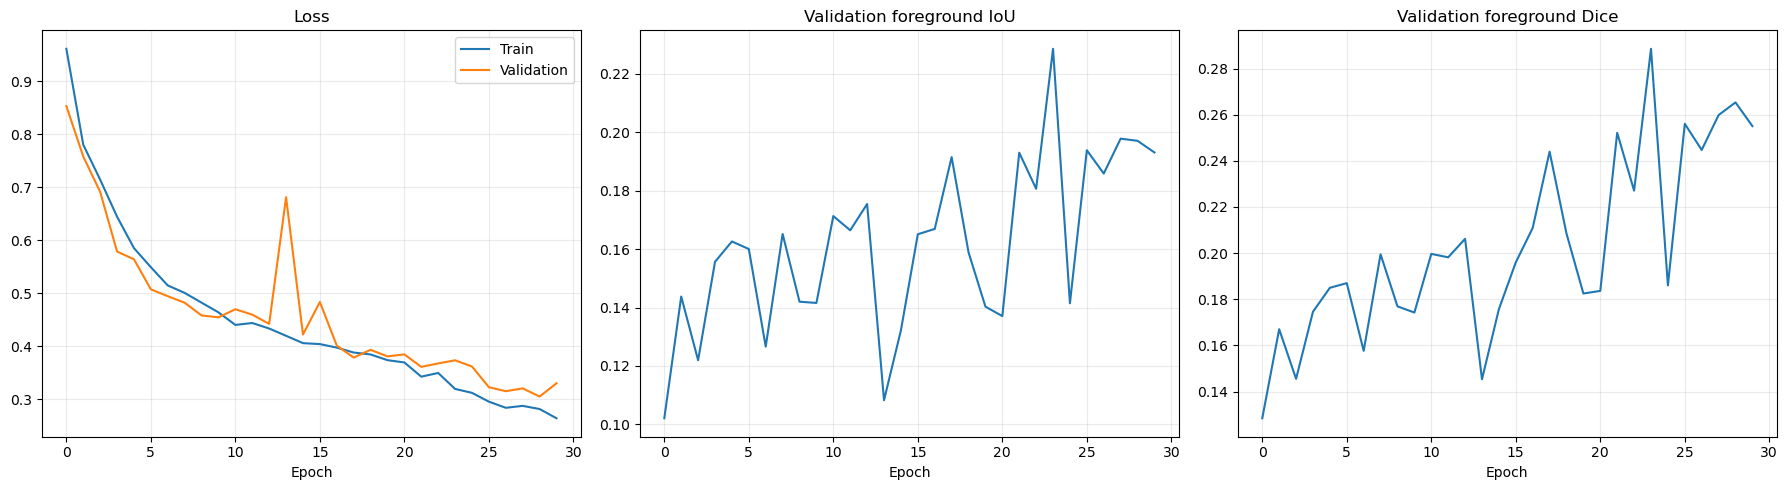

Test loss: 0.4199778172704909
Pixel accuracy: 0.8826408982276917
Foreground mean IoU: 0.1758577226435217
Foreground mean Dice: 0.2247903298008065


,Class ID,Class,IoU,Dice,Trainable
0,0,background,0.833370,0.909113,False
1,1,text,0.865227,0.927744,True
2,2,image,0.556135,0.714764,True
3,3,line_drawing,0.000000,0.000000,True
4,4,graphic,0.092329,0.169049,True
5,5,table,0.121875,0.217270,True
6,6,chart,0.000000,0.000000,True
7,7,separator,0.123012,0.219075,True
8,8,maths,0.000000,0.000000,True
9,9,noise,0.000000,0.000000,True


In [42]:

# 18. Training curves and test evaluation

history_df = pd.DataFrame(history)
history_df.to_csv(HISTORY_PATH, index=False)

fig, ax = plt.subplots(1, 3, figsize=(18, 5))
ax[0].plot(history["train_loss"], label="Train")
ax[0].plot(history["val_loss"], label="Validation")
ax[0].set_title("Loss"); ax[0].legend()
ax[1].plot(history["val_iou"]); ax[1].set_title("Validation foreground IoU")
ax[2].plot(history["val_dice"]); ax[2].set_title("Validation foreground Dice")
for a in ax:
    a.set_xlabel("Epoch"); a.grid(alpha=0.25)
plt.tight_layout(); plt.show()

checkpoint = torch.load(CHECKPOINT_PATH, map_location=DEVICE, weights_only=False)
model.load_state_dict(checkpoint["model_state_dict"])
model.eval()

test_metrics = validate(model, test_loader, criterion, DEVICE)

print("Test loss:", test_metrics["loss"])
print("Pixel accuracy:", test_metrics["pixel_accuracy"])
print("Foreground mean IoU:", test_metrics["mean_iou"])
print("Foreground mean Dice:", test_metrics["mean_dice"])

results_df = pd.DataFrame([
    {
        "Class ID": i,
        "Class": CLASS_NAMES[i],
        "IoU": test_metrics["iou_per_class"][i],
        "Dice": test_metrics["dice_per_class"][i],
        "Trainable": i != 0,
    }
    for i in range(len(CLASS_NAMES))
])
display(results_df)
results_df.to_csv(RESULTS_PATH, index=False)


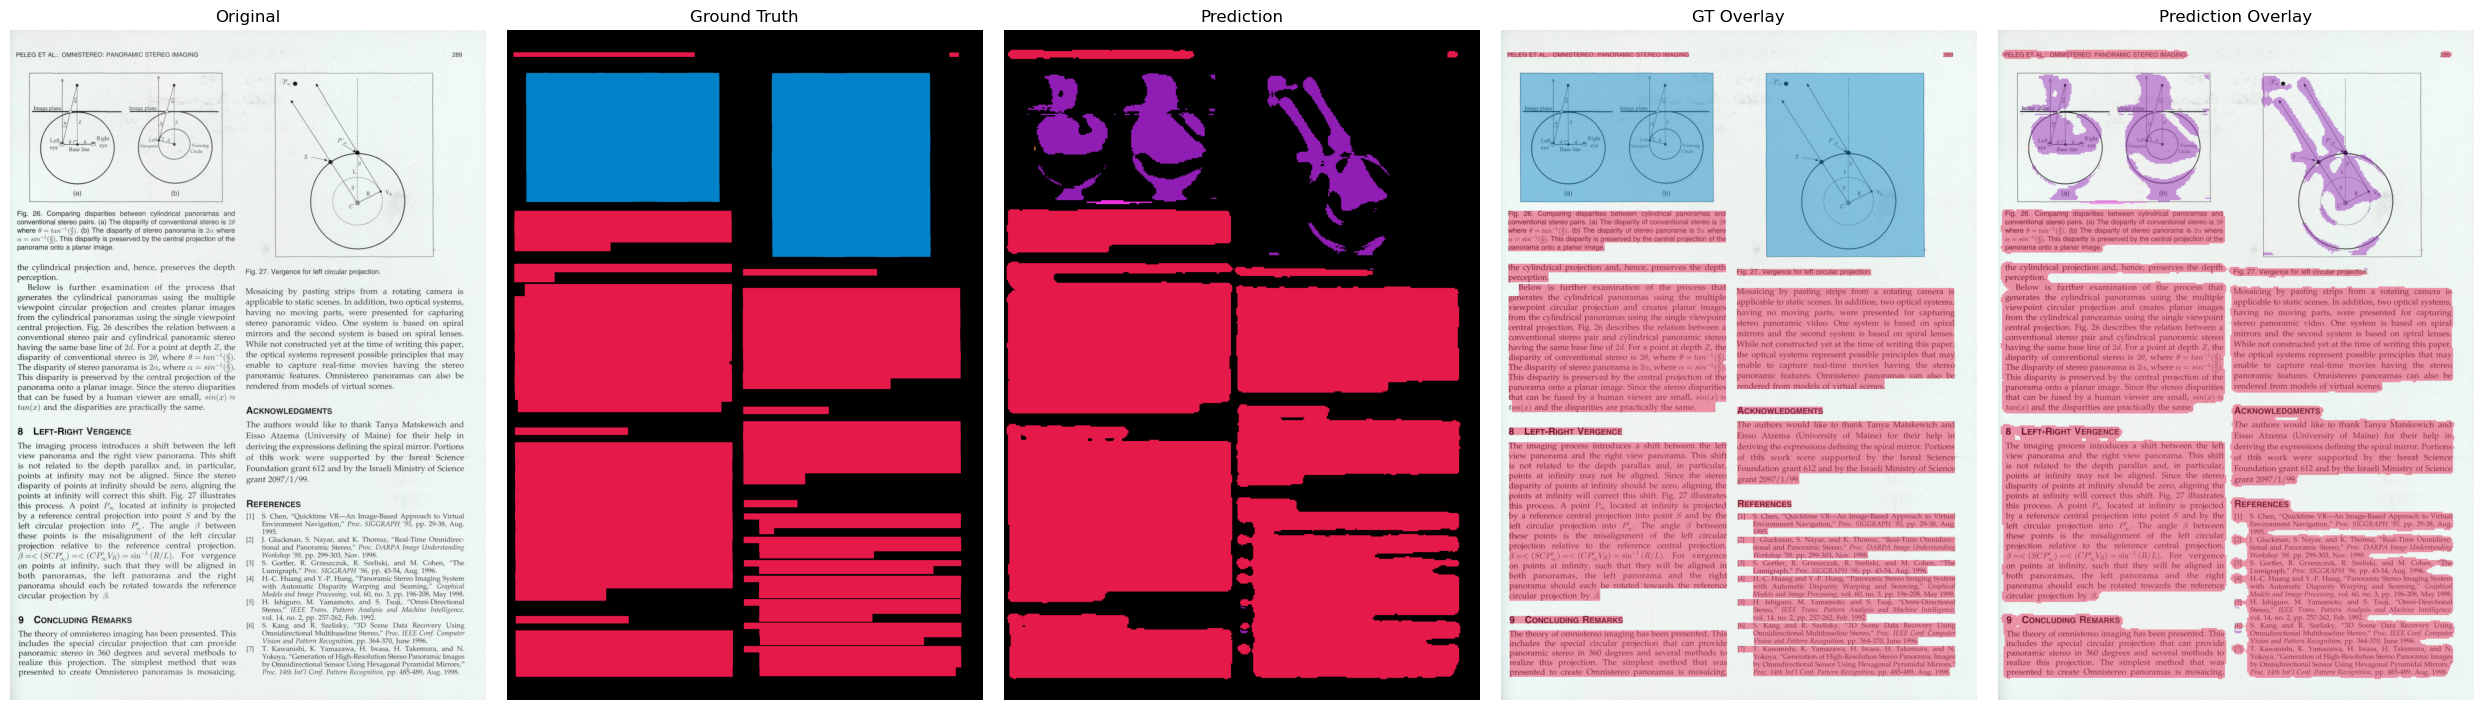

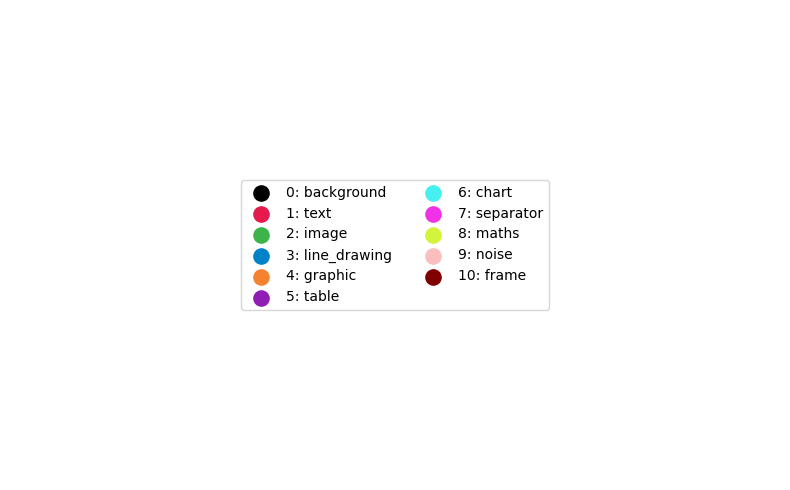

In [53]:

# 19. Original-coordinate inference

@torch.no_grad()
def predict_image(model, image_path, image_size, device, threshold=0.50):
    original = np.asarray(Image.open(image_path).convert("RGB"), dtype=np.uint8)
    blank = np.zeros(original.shape[:2], dtype=np.uint8)

    padded_image, _ = letterbox(original, blank, image_size)

    tensor = torch.from_numpy(
        padded_image.astype(np.float32).transpose(2, 0, 1) / 255.0
    ).unsqueeze(0).to(device)

    logits = model(tensor)
    padded_prediction = logits_to_mask(logits, threshold)[0].cpu().numpy().astype(np.uint8)

    h, w = original.shape[:2]
    scale = min(image_size / w, image_size / h)
    nw, nh = max(1, round(w * scale)), max(1, round(h * scale))
    left, top = (image_size - nw) // 2, (image_size - nh) // 2

    cropped = padded_prediction[top:top+nh, left:left+nw]
    prediction = cv2.resize(cropped, (w, h), interpolation=cv2.INTER_NEAREST)

    return original, prediction

def visualize_prediction(item):
    original, prediction = predict_image(
        model, item["image"], IMAGE_SIZE, DEVICE, BACKGROUND_THRESHOLD
    )
    gt = np.asarray(Image.open(item["mask"]), dtype=np.uint8)

    if prediction.shape != gt.shape:
        raise ValueError(f"Prediction/GT mismatch: {prediction.shape} vs {gt.shape}")

    fig, ax = plt.subplots(1, 5, figsize=(25, 7))
    ax[0].imshow(original); ax[0].set_title("Original")
    ax[1].imshow(colorize_mask(gt)); ax[1].set_title("Ground Truth")
    ax[2].imshow(colorize_mask(prediction)); ax[2].set_title("Prediction")
    ax[3].imshow(overlay_mask(original, gt)); ax[3].set_title("GT Overlay")
    ax[4].imshow(overlay_mask(original, prediction)); ax[4].set_title("Prediction Overlay")
    for a in ax: a.axis("off")
    plt.tight_layout(); plt.show()

visualize_prediction(test_items[0])
show_class_legend()


In [44]:

# 20. Save test predictions in original page coordinates

for item in tqdm(test_items, desc="Saving predictions"):
    _, prediction = predict_image(
        model, item["image"], IMAGE_SIZE, DEVICE, BACKGROUND_THRESHOLD
    )
    Image.fromarray(prediction, mode="L").save(
        PREDICTION_DIR / f"{Path(item['image']).stem}.png"
    )

print("Predictions:", PREDICTION_DIR)


Saving predictions: 100%|██████████| 72/72 [00:09<00:00,  7.88it/s]

Predictions: /data1/students/abhista/datasets/PRImALayoutAnalysisDataset/predictions_corrected



## Class-specific deep feature vectors

Features are extracted from the U-Net **bottleneck**, before decoding. For every document and foreground class, the bottleneck feature map is spatially downsampled to the mask resolution and averaged over pixels belonging to that class.

The resulting tensor has shape:

`[number_of_images, 10_foreground_classes, feature_dimension]`

The feature dimension is obtained from `model.feature_dim`, so it is never incorrectly hard-coded to 1024.


In [45]:

# 21. Feature extraction from the U-Net bottleneck

@torch.no_grad()
def extract_class_features(model, images, raw_masks):
    images = images.to(DEVICE)
    raw_masks = raw_masks.to(DEVICE)

    _, bottleneck = model(images, return_features=True)
    b, c, hb, wb = bottleneck.shape

    small_mask = F.interpolate(
        raw_masks.unsqueeze(1).float(),
        size=(hb, wb),
        mode="nearest"
    ).squeeze(1).long()

    features = torch.zeros(b, NUM_CLASSES, c, device=DEVICE)
    present = torch.zeros(b, NUM_CLASSES, dtype=torch.bool, device=DEVICE)

    for bi in range(b):
        for fi in range(NUM_CLASSES):
            class_id = fi + 1
            selected = small_mask[bi] == class_id
            if selected.any():
                features[bi, fi] = bottleneck[bi, :, selected].mean(dim=1)
                present[bi, fi] = True

    return features, present

images, _, raw_masks = next(iter(test_loader))
class_features, class_present = extract_class_features(model, images, raw_masks)

print("Feature tensor:", class_features.shape)
print("Presence tensor:", class_present.shape)
print("Feature dimension:", model.feature_dim)


Feature tensor: torch.Size([4, 10, 512])
Presence tensor: torch.Size([4, 10])
Feature dimension: 512


In [46]:

# 22. Extract all test-set class vectors and prototypes

all_features = []
all_presence = []

for images, _, raw_masks in tqdm(test_loader, desc="Extracting class features"):
    features, present = extract_class_features(model, images, raw_masks)
    all_features.append(features.cpu())
    all_presence.append(present.cpu())

all_features = torch.cat(all_features, dim=0)
all_presence = torch.cat(all_presence, dim=0)

class_prototypes = {}

for fi, class_name in enumerate(FOREGROUND_CLASS_NAMES):
    vectors = all_features[all_presence[:, fi], fi, :]

    if len(vectors) == 0:
        print(class_name, ": no examples")
        continue

    class_prototypes[class_name] = vectors.mean(dim=0)
    print(class_name, "->", tuple(class_prototypes[class_name].shape))

print("All features:", all_features.shape)


Extracting class features: 100%|██████████| 18/18 [00:04<00:00,  3.76it/s]

text -> (512,)
image -> (512,)
line_drawing -> (512,)
graphic -> (512,)
table -> (512,)
chart -> (512,)
separator -> (512,)
maths -> (512,)
noise -> (512,)
frame -> (512,)
All features: torch.Size([72, 10, 512])


In [47]:

# 23. Save feature vectors and class prototypes

torch.save({
    "features": all_features,
    "class_presence": all_presence,
    "class_names": FOREGROUND_CLASS_NAMES,
    "feature_dimension": model.feature_dim,
    "feature_source": "U-Net bottleneck",
}, FEATURE_DIR / "test_class_features.pt")

torch.save({
    "prototypes": class_prototypes,
    "class_names": FOREGROUND_CLASS_NAMES,
    "feature_dimension": model.feature_dim,
    "feature_source": "U-Net bottleneck",
}, FEATURE_DIR / "class_prototypes.pt")

prototype_rows = []
for name, vector in class_prototypes.items():
    row = {"class": name}
    row.update({f"feature_{i+1}": float(v) for i, v in enumerate(vector.numpy())})
    prototype_rows.append(row)

prototype_df = pd.DataFrame(prototype_rows)
prototype_df.to_csv(FEATURE_DIR / "class_prototypes.csv", index=False)

print("Saved feature analysis to:", FEATURE_DIR)


Saved feature analysis to: /data1/students/abhista/datasets/PRImALayoutAnalysisDataset/deep_features_corrected


,text,image,line_drawing,graphic,table,chart,separator,maths,noise,frame
text,0.000000,,,,,,,,,
image,0.230191,0.0,,,,,,,,
line_drawing,0.499846,0.250292,0.0,,,,,,,
graphic,0.731293,0.38648,0.85506,0.0,,,,,,
table,0.546669,0.311421,0.981261,0.899669,0.0,,,,,
chart,0.573946,0.307711,0.964502,0.903569,0.961147,0.0,,,,
separator,0.750284,0.326709,0.551336,0.821051,0.615164,0.624533,0.0,,,
maths,0.770505,0.101873,0.543872,0.7092,0.602384,0.571291,0.855872,0.0,,
noise,0.272756,0.848455,0.361829,0.493613,0.403204,0.436929,0.431292,0.152697,0.0,
frame,0.820744,0.128098,0.514445,0.72091,0.564852,0.596679,0.83977,0.857108,0.172726,0.0


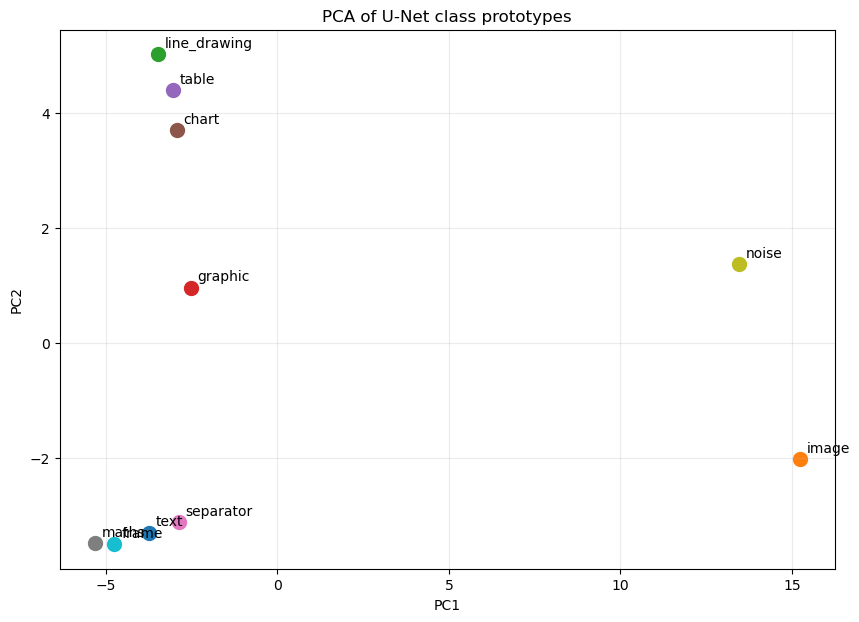

In [48]:

# 24. Prototype cosine similarity and PCA

names = list(class_prototypes.keys())

if len(names) >= 2:
    matrix = F.normalize(
        torch.stack([class_prototypes[n] for n in names]), p=2, dim=1
    )
    similarity = (matrix @ matrix.T).numpy()

    similarity_df = pd.DataFrame(similarity, index=names, columns=names)

    # Keep the upper triangle empty for readable pairwise analysis.
    upper = np.triu(np.ones(similarity_df.shape, dtype=bool), k=1)
    similarity_df = similarity_df.mask(upper, "")
    for i in range(len(names)):
        similarity_df.iloc[i, i] = 0.0

    display(similarity_df)

    X = np.stack([class_prototypes[n].numpy() for n in names])
    X2 = PCA(n_components=2, random_state=SEED).fit_transform(X)

    plt.figure(figsize=(10, 7))
    for i, name in enumerate(names):
        plt.scatter(X2[i, 0], X2[i, 1], s=100)
        plt.annotate(name, (X2[i, 0], X2[i, 1]), xytext=(5, 5),
                     textcoords="offset points")
    plt.title("PCA of U-Net class prototypes")
    plt.xlabel("PC1"); plt.ylabel("PC2")
    plt.grid(alpha=0.25)
    plt.show()
else:
    print("Not enough class prototypes for similarity/PCA analysis.")



## Key corrections

- **XML parsing:** namespace-safe parsing, both PAGE coordinate forms, malformed-polygon checks, boundary clipping, and overlap reporting.
- **Class IDs:** one mapping is used throughout. `0` is implicit background; `1..10` are the ten PRImA classes.
- **Training:** the U-Net has **10 output channels**, not 11. Background is ignored by the training loss because PRImA does not annotate it as a region.
- **Prediction:** softmax → per-pixel foreground `argmax` → confidence threshold → background `0`.
- **Alignment:** aspect ratio is preserved and image/mask use the exact same letterbox transform. Masks use nearest-neighbor interpolation.
- **Metrics:** IoU/Dice are calculated per class and mean foreground metrics are reported; background remains visible as a reference metric.
- **Visualization:** fixed contrasting colors are reused in masks, overlays, and legends.
- **Feature vectors:** vectors come directly from the U-Net bottleneck and use the actual bottleneck channel dimension rather than an assumed 1024 dimensions.
- **Reproducibility:** deterministic seeds, saved checkpoints, history, evaluation results, masks, predictions, and feature representations are retained.
